In [53]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict, List, Annotated
import operator
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.checkpoint.memory import InMemorySaver

In [54]:
class JokeState(TypedDict):
    topic: str
    joke: str
    joke_explanation: str

In [55]:
load_dotenv()

model = ChatGroq(
    model='llama-3.3-70b-versatile',
    temperature=0.7
)

In [56]:
def generate_joke(state: JokeState):
    prompt = f"Generate a joke based on topic: {state['topic']}"
    response = model.invoke(prompt).content

    return {'joke': response}


In [57]:
def explain_joke(state: JokeState):
    prompt = f"Explain the given joke: {state['joke']}"
    response = model.invoke(prompt).content

    return {'joke_explanation': response}

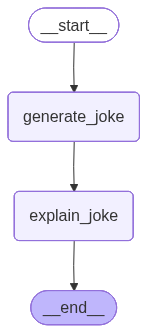

In [58]:
check_pointer = InMemorySaver()
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('explain_joke', explain_joke)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'explain_joke')
graph.add_edge('explain_joke', END)

workflow = graph.compile(checkpointer = check_pointer)

workflow

In [59]:
config1 = {'configurable': {'thread_id': '1'}}
initial_state = {'topic': "Pizza"}
final_state = workflow.invoke(initial_state, config=config1)

In [60]:
final_state

{'topic': 'Pizza',
 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.',
 'joke_explanation': 'The joke is a play on words. "Crusty" has a double meaning here:\n\n1. A pizza has a crust, which is the outer layer of the pizza.\n2. "Feeling crusty" is an idiomatic expression that means being irritable, grumpy, or in a bad mood.\n\nSo, the joke is making a pun on the word "crusty" to create a humorous connection between the pizza\'s physical characteristics (having a crust) and its emotional state (being in a bad mood). It\'s a lighthearted and clever way to create a joke.'}

In [61]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'joke_explanation': 'The joke is a play on words. "Crusty" has a double meaning here:\n\n1. A pizza has a crust, which is the outer layer of the pizza.\n2. "Feeling crusty" is an idiomatic expression that means being irritable, grumpy, or in a bad mood.\n\nSo, the joke is making a pun on the word "crusty" to create a humorous connection between the pizza\'s physical characteristics (having a crust) and its emotional state (being in a bad mood). It\'s a lighthearted and clever way to create a joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12834f-25ae-628a-8002-40c141eba529'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-03-25T10:25:29.464849+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12834f-20d6-6589-8001-278a3767e502'}}, tas

In [62]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why was the pizza in a bad mood?\n\nBecause it was feeling a little crusty.', 'joke_explanation': 'The joke is a play on words. "Crusty" has a double meaning here:\n\n1. A pizza has a crust, which is the outer layer of the pizza.\n2. "Feeling crusty" is an idiomatic expression that means being irritable, grumpy, or in a bad mood.\n\nSo, the joke is making a pun on the word "crusty" to create a humorous connection between the pizza\'s physical characteristics (having a crust) and its emotional state (being in a bad mood). It\'s a lighthearted and clever way to create a joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12834f-25ae-628a-8002-40c141eba529'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-03-25T10:25:29.464849+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f12834f-20d6-6589-8001-278a3767e502'}}, ta

In [63]:
config2 = {'configurable': {'thread_id': '2'}}
initial_state = {'topic': "pasta"}
final_state = workflow.invoke(initial_state, config=config2)

In [64]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.', 'joke_explanation': 'A clever play on words. The joke is funny because it uses a common phrase associated with relationships ("tangled up") and gives it a literal twist. \n\nIn this joke, "tangled up" has a double meaning:\n1. **Emotional entanglement**: In relationships, people can become emotionally entangled, meaning they become deeply involved and connected with each other. This can sometimes lead to complicated situations or feelings.\n2. **Physical entanglement**: Spaghetti, being a long, thin, and flexible food item, can easily become physically tangled or knotted when it\'s not properly managed.\n\nThe punchline "afraid of getting tangled up in a relationship" is humorous because it takes the common phrase and applies it to spaghetti, which is already prone to physical tangling. It\'s as if the spaghetti is worried th

In [65]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.', 'joke_explanation': 'A clever play on words. The joke is funny because it uses a common phrase associated with relationships ("tangled up") and gives it a literal twist. \n\nIn this joke, "tangled up" has a double meaning:\n1. **Emotional entanglement**: In relationships, people can become emotionally entangled, meaning they become deeply involved and connected with each other. This can sometimes lead to complicated situations or feelings.\n2. **Physical entanglement**: Spaghetti, being a long, thin, and flexible food item, can easily become physically tangled or knotted when it\'s not properly managed.\n\nThe punchline "afraid of getting tangled up in a relationship" is humorous because it takes the common phrase and applies it to spaghetti, which is already prone to physical tangling. It\'s as if the spaghetti is worried tha

In [66]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.', 'joke_explanation': 'A clever play on words. The joke is funny because it uses a common phrase associated with relationships ("tangled up") and gives it a literal twist. \n\nIn this joke, "tangled up" has a double meaning:\n1. **Emotional entanglement**: In relationships, people can become emotionally entangled, meaning they become deeply involved and connected with each other. This can sometimes lead to complicated situations or feelings.\n2. **Physical entanglement**: Spaghetti, being a long, thin, and flexible food item, can easily become physically tangled or knotted when it\'s not properly managed.\n\nThe punchline "afraid of getting tangled up in a relationship" is humorous because it takes the common phrase and applies it to spaghetti, which is already prone to physical tangling. It\'s as if the spaghetti is worried th

In [67]:
config3 =  {'configurable': {'thread_id': '2', 'checkpoint_id': '1f12834f-7613-626e-8000-5c0bd35d38fb'}}
workflow.get_state(config3)

StateSnapshot(values={'topic': 'pasta'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f12834f-7613-626e-8000-5c0bd35d38fb'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-03-25T10:25:37.894845+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f12834f-760f-6371-bfff-496649b32c28'}}, tasks=(PregelTask(id='cce85fbb-46e1-d732-f3bd-3b7d82736c81', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.'}),), interrupts=())

In [68]:
workflow.invoke(None, {'configurable': {'thread_id': '2', 'checkpoint_id': '1f12834f-7613-626e-8000-5c0bd35d38fb'}})

{'topic': 'pasta',
 'joke': 'Why did the pasta go to therapy?\n\nBecause it was feeling a little "drained" and wanted to work through some "saucy" issues.',
 'joke_explanation': 'A clever joke. The joke is a play on words, using pasta-related terms to create a humorous connection to the concept of therapy. Here\'s a breakdown:\n\n1. "Drained" has a double meaning:\n   - In a literal sense, pasta is often drained of water after being cooked.\n   - In an emotional sense, "drained" can also mean feeling exhausted or depleted, which is a common reason people might seek therapy.\n\n2. "Saucy" issues is another wordplay:\n   - In a literal sense, pasta is often served with sauce.\n   - In an idiomatic sense, "saucy" can also mean cheeky, provocative, or related to sensitive topics. In this joke, "saucy issues" likely refers to personal problems or conflicts that the pasta wants to work through in therapy.\n\nThe joke relies on this wordplay to create a humorous connection between the concept

In [69]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta go to therapy?\n\nBecause it was feeling a little "drained" and wanted to work through some "saucy" issues.', 'joke_explanation': 'A clever joke. The joke is a play on words, using pasta-related terms to create a humorous connection to the concept of therapy. Here\'s a breakdown:\n\n1. "Drained" has a double meaning:\n   - In a literal sense, pasta is often drained of water after being cooked.\n   - In an emotional sense, "drained" can also mean feeling exhausted or depleted, which is a common reason people might seek therapy.\n\n2. "Saucy" issues is another wordplay:\n   - In a literal sense, pasta is often served with sauce.\n   - In an idiomatic sense, "saucy" can also mean cheeky, provocative, or related to sensitive topics. In this joke, "saucy issues" likely refers to personal problems or conflicts that the pasta wants to work through in therapy.\n\nThe joke relies on this wordplay to create a humorous connection

In [71]:
workflow.update_state({'configurable': {'thread_id': '2', 'checkpoint_ns': '','checkpoint_id': '1f12834f-7613-626e-8000-5c0bd35d38fb'}}, {'topic': 'samossa'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f12835f-6c30-6c2c-8001-4eb353f5b811'}}

In [73]:
workflow.invoke(None, {'configurable': {'thread_id': '2', 'checkpoint_ns': '','checkpoint_id': '1f12834f-7613-626e-8000-5c0bd35d38fb'}})

{'topic': 'pasta',
 'joke': 'Why did the spaghetti refuse to get married?\n\nBecause it was afraid of getting tangled up in a relationship.',
 'joke_explanation': 'A clever play on words. The joke is funny because it uses a common phrase "tangled up in a relationship" (meaning to be deeply involved or entangled in a romantic partnership) and gives it a literal twist. \n\nIn this case, the spaghetti (a long, thin, and flexible food made from pasta) is afraid of getting "tangled up" because it can actually get physically tangled or knotted, much like how it does when it\'s cooked or handled. The joke relies on this double meaning of "tangled up" to create a humorous connection between the setup (the spaghetti refusing to get married) and the punchline (the fear of getting tangled up in a relationship). It\'s a lighthearted and clever play on words that creates a amusing and unexpected twist.'}